In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(
    "../data/raw/complaints.csv",
    nrows=1000000
)

C:\Users\samiy\AppData\Local\Temp\ipykernel_37332\3857105913.py:1: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [3]:
print(df.shape)
df.head()

(1000000, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype
---  ------                        --------------    -----
 0   Date received                 1000000 non-null  str  
 1   Product                       1000000 non-null  str  
 2   Sub-product                   999054 non-null   str  
 3   Issue                         1000000 non-null  str  
 4   Sub-issue                     980134 non-null   str  
 5   Consumer complaint narrative  146189 non-null   str  
 6   Company public response       272157 non-null   str  
 7   Company                       1000000 non-null  str  
 8   State                         998109 non-null   str  
 9   ZIP code                      999986 non-null   str  
 10  Tags                          27853 non-null    str  
 11  Consumer consent provided?    436678 non-null   str  
 12  Submitted via                 1000000 non-null  str  
 13  Date sent

In [5]:
df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")

In [6]:
df["Date received"].isna().sum()

np.int64(0)

In [7]:
df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             891219
Debt collection                                                                  47270
Credit card                                                                      16530
Money transfer, virtual currency, or money service                               13430
Checking or savings account                                                      13091
Mortgage                                                                          4737
Student loan                                                                      4441
Vehicle loan or lease                                                             3426
Payday loan, title loan, personal loan, or advance loan                           1972
Prepaid card                                                                      1085
Credit reporting, credit repair services, or other personal consumer reports       997
Credit reporting                   

In [8]:
product_counts = df["Product"].value_counts()

print(product_counts)

Product
Credit reporting or other personal consumer reports                             891219
Debt collection                                                                  47270
Credit card                                                                      16530
Money transfer, virtual currency, or money service                               13430
Checking or savings account                                                      13091
Mortgage                                                                          4737
Student loan                                                                      4441
Vehicle loan or lease                                                             3426
Payday loan, title loan, personal loan, or advance loan                           1972
Prepaid card                                                                      1085
Credit reporting, credit repair services, or other personal consumer reports       997
Credit reporting                   

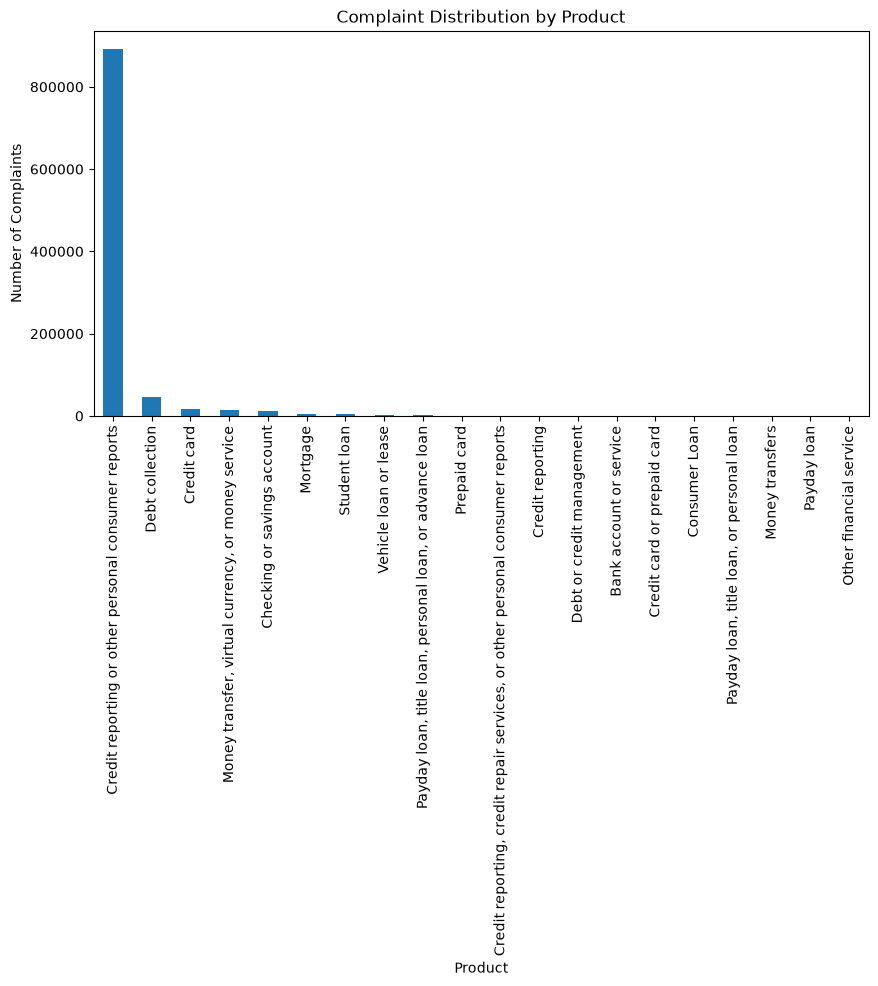

In [9]:
import matplotlib.pyplot as plt

product_counts.plot(kind="bar", figsize=(10,5))
plt.title("Complaint Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.show()

In [10]:
df["Company"].value_counts().head(10)

Company
EQUIFAX, INC.                             307080
TRANSUNION INTERMEDIATE HOLDINGS, INC.    302915
Experian Information Solutions Inc.       268027
Block, Inc.                                 6936
CAPITAL ONE FINANCIAL CORPORATION           6067
CBC Companies, Inc.                         4849
Early Warning Services, LLC                 4631
JPMORGAN CHASE & CO.                        3984
BANK OF AMERICA, NATIONAL ASSOCIATION       3420
Resurgent Capital Services L.P.             3199
Name: count, dtype: int64

In [11]:
df["word_count"] = (
    df["Consumer complaint narrative"]
    .astype(str)
    .str.split()
    .str.len()
)

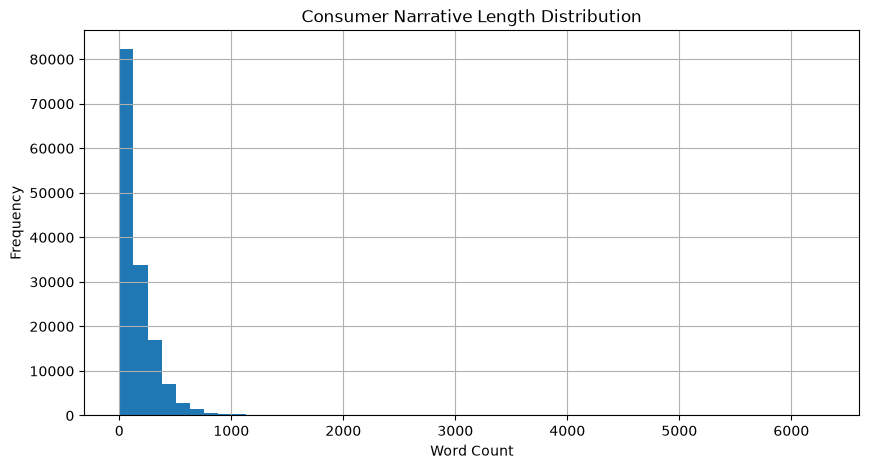

In [12]:
plt.figure(figsize=(10,5))

df["word_count"].hist(bins=50)

plt.title("Consumer Narrative Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [13]:
df[df["word_count"] < 20][
    ["Consumer complaint narrative", "word_count"]
].head()

,Consumer complaint narrative,word_count
17670,"Ongoing payment situation with Best Buy, my pa...",18.0
33288,CHARGE-OFF DEBT IS TAXABLE INCOME AND CAN NO L...,19.0
34384,"Upon reviewing my credit report, I have identi...",18.0
35451,"Upon reviewing my credit report, I have identi...",18.0
35747,"Upon reviewing my credit report, I have identi...",18.0


In [14]:
df.sort_values(
    "word_count",
    ascending=False
)[
    ["word_count", "Consumer complaint narrative"]
].head()

,word_count,Consumer complaint narrative
527180,6291.0,I have composed this complaint based on 1. I W...
695797,5847.0,I have composed this complaint based on XXXX. ...
959393,5635.0,============================== COMPLAINT =====...
974764,5378.0,I have identified several inaccuracies on my c...
315598,5307.0,Summary of Demand Please take notice that I he...


<Axes: xlabel='Date received'>

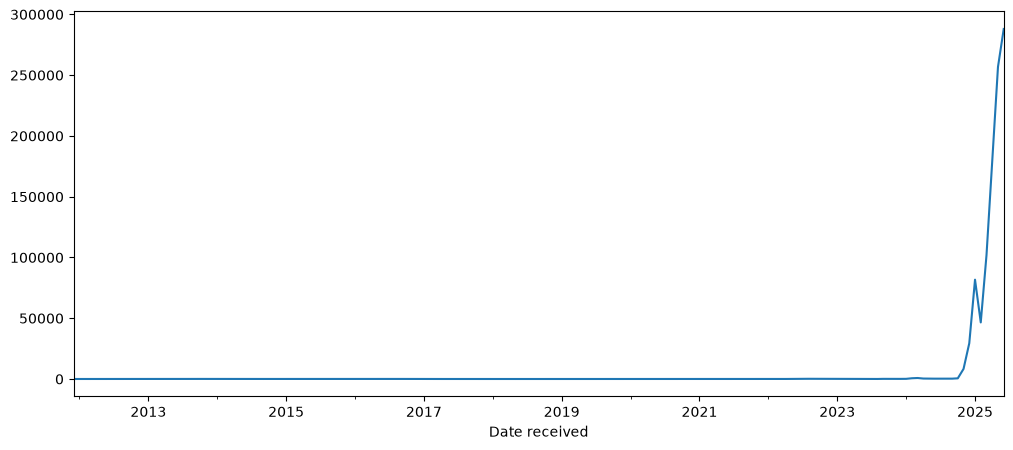

In [15]:
monthly = df.groupby(df["Date received"].dt.to_period("M")).size()

monthly.plot(figsize=(12,5))

In [16]:
target_products = [
    "Credit card",
    "Checking or savings account",
    "Money transfer, virtual currency, or money service",
    "Payday loan, title loan, personal loan, or advance loan"
]

filtered_df = df[df["Product"].isin(target_products)].copy()

print(filtered_df.shape)
print(filtered_df["Product"].value_counts())

(45023, 19)
Product
Credit card                                                16530
Money transfer, virtual currency, or money service         13430
Checking or savings account                                13091
Payday loan, title loan, personal loan, or advance loan     1972
Name: count, dtype: int64


In [17]:
filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"].notna()
]

In [18]:
filtered_df["clean_text"] = (
    filtered_df["Consumer complaint narrative"]
    .str.lower()
)

In [19]:
import re

def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

filtered_df["clean_text"] = (
    filtered_df["clean_text"]
    .apply(remove_special_chars)
)

In [22]:
boilerplate_patterns = [
    r"i am writing to file a complaint",
    r"i would like to file a complaint",
    r"this complaint concerns"
]

def remove_boilerplate(text):
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)
    return text.strip()

filtered_df["clean_text"] = (
    filtered_df["clean_text"]
    .apply(remove_boilerplate)
)

In [23]:
filtered_df["clean_text"] = (
    filtered_df["clean_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [24]:
filtered_df[
    [
        "Consumer complaint narrative",
        "clean_text"
    ]
].head()

,Consumer complaint narrative,clean_text
12237,A XXXX XXXX card was opened under my name by a...,a xxxx xxxx card was opened under my name by a...
12532,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,"Dear CFPB, I have a secured credit card with c...",dear cfpb i have a secured credit card with ci...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,b i am writing to dispute the following charge...


In [26]:
filtered_df.shape
filtered_df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,clean_text
12237,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,91.0,a xxxx xxxx card was opened under my name by a...
12532,2025-06-13,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,NaN,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897,109.0,i made the mistake of using my wellsfargo debi...
13280,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,156.0,dear cfpb i have a secured credit card with ci...
13506,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,233.0,i have a citi rewards cards the credit balance...
13955,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,454.0,b i am writing to dispute the following charge...


In [27]:
with_narrative = filtered_df["Consumer complaint narrative"].notna().sum()
without_narrative = filtered_df["Consumer complaint narrative"].isna().sum()

print(with_narrative, without_narrative)

19867 0


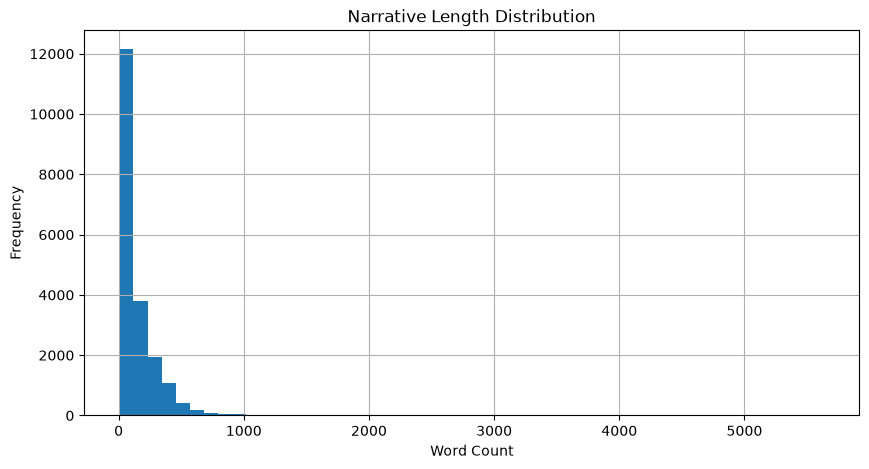

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
filtered_df["word_count"].hist(bins=50)
plt.title("Narrative Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [30]:
filtered_df.to_csv(
    "../data/processed/cfpb_cleaned_financial_products.csv",
    index=False
)

In [31]:
filtered_df["word_count"].describe()

count    19867.000000
mean       165.113152
std        173.377046
min          6.000000
25%         92.000000
50%        106.000000
75%        194.000000
max       5635.000000
Name: word_count, dtype: float64

The consumer complaint narratives show a highly variable length distribution, with an average of 220 words and a median of 177 words. While most complaints are moderately detailed, there exist extreme outliers reaching over 3000 words. This variation highlights the need for a chunking strategy in downstream retrieval-based models to ensure long documents are properly segmented for embedding generation.

In [32]:
filtered_df[["Date received", "Product"]].head()

,Date received,Product
12237,2025-06-13,Credit card
12532,2025-06-13,Checking or savings account
13280,2025-06-12,Credit card
13506,2025-06-12,Credit card
13955,2025-06-09,Credit card


In [33]:
filtered_df["Product"].value_counts()

Product
Money transfer, virtual currency, or money service         9001
Checking or savings account                                5678
Credit card                                                4539
Payday loan, title loan, personal loan, or advance loan     649
Name: count, dtype: int64

In [34]:
sample_df = filtered_df.copy()

In [35]:
sample_df.shape

(19867, 20)

In [36]:
sample_df["Product"].value_counts()

Product
Money transfer, virtual currency, or money service         9001
Checking or savings account                                5678
Credit card                                                4539
Payday loan, title loan, personal loan, or advance loan     649
Name: count, dtype: int64

In [37]:
sample_df = filtered_df.groupby("Product").sample(
    frac=0.6,
    random_state=42
).reset_index(drop=True)

In [38]:
sample_df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID', 'word_count',
       'clean_text'],
      dtype='str')

In [39]:
sample_df.shape
sample_df["Product"].value_counts()

Product
Money transfer, virtual currency, or money service         5401
Checking or savings account                                3407
Credit card                                                2723
Payday loan, title loan, personal loan, or advance loan     389
Name: count, dtype: int64

In [40]:
sample_df["Product"].value_counts(normalize=True)
filtered_df["Product"].value_counts(normalize=True)

Product
Money transfer, virtual currency, or money service         0.453063
Checking or savings account                                0.285801
Credit card                                                0.228469
Payday loan, title loan, personal loan, or advance loan    0.032667
Name: proportion, dtype: float64

The sampled dataset maintains the original distribution of product categories, ensuring that the model reflects real-world complaint frequency patterns rather than artificially balanced classes.

Methodology
Starting Dataset
A cleaned dataset containing approximately 19,867 complaints was used.
Each record includes a consumer complaint narrative and metadata such as product category, issue type, and company.
Stratified Sampling Approach
The dataset was grouped by the Product column.
A proportional random sample was drawn from each product group using a fixed sampling fraction (frac = 0.6).
This ensures each product category contributes to the final dataset in proportion to its original frequency.The final sampled dataset (approximately 11,920 complaints) maintains the original product distribution:

Money transfer, virtual currency, or money service: ~45%
Checking or savings account: ~29%
Credit card: ~23%
Payday loan / personal loan: ~3%

This confirms that the sampling process preserved the natural imbalance present in real-world financial complaint data

LangChain RecursiveCharacterTextSplitter

In [41]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

ModuleNotFoundError: No module named 'langchain.text_splitter'